## Set Experiment Values

In [1]:
# What is the ID for the current participant?
PARTICIPANT_ID = "TpOnaM"

# Load

In [2]:
import numpy as np
import parse
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations

# load data
input_file = './calibration-results/{}.txt'.format(PARTICIPANT_ID)
with open(input_file, 'r') as f:
    lmk, lmk_world, trigger = parse.parse(f.read())

In [3]:
# flatten 21 x 3 features into a vector of length 63
lmk = lmk.reshape((-1, trigger.size))

In [4]:
# cut stream of data into trials
idx_trial_start, y, trial_length = parse.split_trial(trigger=trigger)
x_raw = np.stack([lmk[:, idx: idx + trial_length] for idx in idx_trial_start], axis=-1)

# dimensions: features (21 x 3), trial
x_raw = x_raw.mean(axis=1)
x_raw.shape

(63, 18)

## Transform Hand Landmarks

In [5]:
from register import HandRegister, plot_hand, reshape_to_landmark

hand_reg = HandRegister()
hand_reg.fit(x_raw)
x = hand_reg.transform(x_raw)

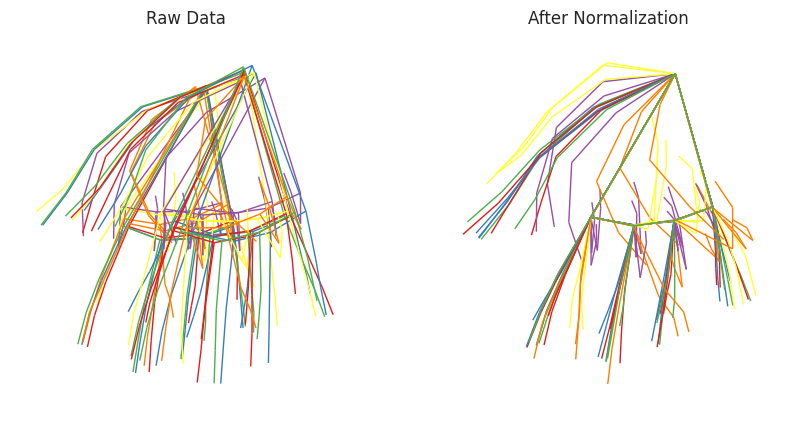

In [6]:
cmap = plt.get_cmap('Set1')

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 5)
for ax_idx, (label, x) in enumerate([('Raw Data', x_raw),
                                     ('After Normalization', x)]):
    x_reshape = reshape_to_landmark(x)
    plt.sca(ax[ax_idx])
    for trial_idx in range(x_reshape.shape[2]):
        _x = x_reshape[:, :, trial_idx]
    
        # networkx insists on a 2d array
        color = np.atleast_2d(cmap(y[trial_idx]))
        plot_hand(_x[:, 0], _x[:, 1], edge_color=color)
    ax[ax_idx].title.set_text(label)

## Classification

In [7]:
from norm_class import NormClass
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# todo: this should be standard above
x_sklearn = x.T

n_splits = 3

k_fold = StratifiedKFold(n_splits=n_splits)

norm_class = NormClass()

y_pred = np.empty(x_sklearn.shape[0])
y_prob = np.empty((x_sklearn.shape[0], len(np.unique(y))))
for train_idx, test_idx in k_fold.split(x_sklearn, y):
    x_train = x_sklearn[train_idx, :]
    y_train = y[train_idx]
    x_test = x_sklearn[test_idx, :]

    norm_class.fit(x_train, y_train)
    y_pred[test_idx] = norm_class.predict(x_test)
    y_prob[test_idx, :] = norm_class.predict_apost(x_test)

conf_mat = confusion_matrix(y_pred=y_pred, y_true=y)

In [8]:
x_sklearn.shape

(18, 63)

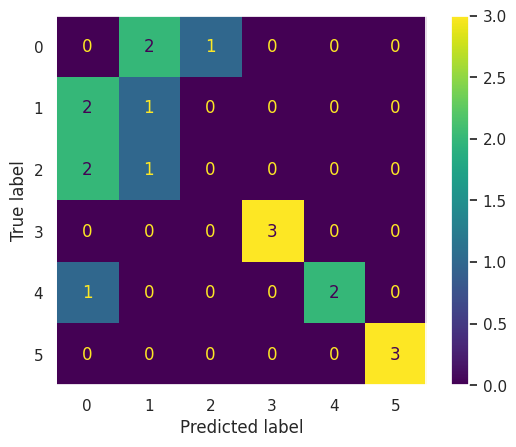

In [9]:
ConfusionMatrixDisplay(conf_mat).plot()
plt.grid(False)

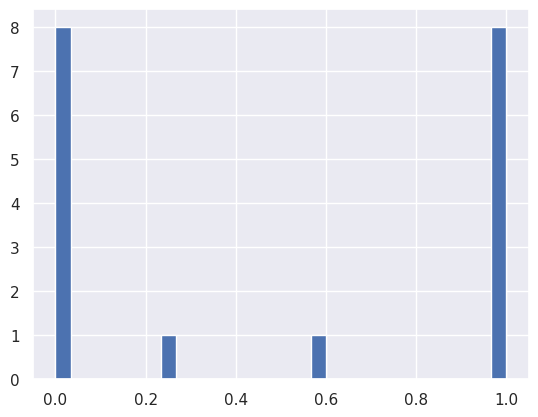

In [10]:
# for most samples, its quite confident in the correct answer
prob_correct = y_prob[range(y_prob.shape[0]), y]
plt.hist(prob_correct, bins=30);

## Ordered Hand Symbols (incomplete)

Identify the hand symbol whose exclusion maximizes accuracy.  This "worst" hand symbol is stored in the right of `best_to_worst` and the process repeats.  Allows us to choose the "best" n hand symbols as `best_to_worst[:n]`

In [11]:
# Group by trial 
label_vals = np.unique(y)

# Initialize dictionary to store separated data
separated_data = {label: [] for label in label_vals}

# Iterate over trials and separate data based on labels
for trial, label in zip(x.T, y):
    separated_data[label].append(trial)

# Convert lists to arrays
for label, trials in separated_data.items():
    separated_data[label] = np.array(trials).reshape(3, 3 * 21)

In [28]:
x.shape

(63, 18)

In [29]:
y.shape

(18,)

In [12]:
n_splits = 3

k_fold = StratifiedKFold(n_splits=n_splits)

norm_class = NormClass()

In [45]:
from sklearn.neighbors import KNeighborsClassifier

norm_class = KNeighborsClassifier(n_neighbors=1)

In [54]:
def find_best_combo2(remaining_labels):
    acc_dict = dict()
    for label_to_rm in remaining_labels:
        # get a bool_idx of all active ones
        bool_idx = np.array([_y != label_to_rm for _y in y])
        _x = x_sklearn[bool_idx, :]
        _y = y[bool_idx]

        # comptue accuracy
        n_trial, n_feat = _x.shape
        y_pred = np.empty(n_trial)
        for train_idx, test_idx in k_fold.split(_x, _y):
            x_train = _x[train_idx, :]
            y_train = _y[train_idx]
            x_test = _x[test_idx, :]

            norm_class.fit(x_train, y_train)
            y_pred[test_idx] = norm_class.predict(x_test)

        acc_dict[label_to_rm] = accuracy_score(y_pred=y_pred, y_true =_y)
    

    weakest_link = max(acc_dict, key=acc_dict.get)

    return list(set(remaining_labels) - {weakest_link})



In [47]:
find_best_combo2(remaining_labels=list(range(5)))

{0: 0.8,
 1: 0.5333333333333333,
 2: 0.6666666666666666,
 3: 0.4666666666666667,
 4: 0.5333333333333333}

In [26]:
def find_best_combo(remaining_labels):
    # Set up combinations
    combos = list(combinations(remaining_labels, len(remaining_labels) - 1))

    scores = np.zeros(len(combos))
    matrices = []

    for scr_idx, comb in enumerate(combos):
        num_samples = 0
        for l in comb:
            num_samples += separated_data[l].shape[0]

        x_classify = np.zeros((num_samples, 21*3))
        y_subset = np.zeros(num_samples)
        sample_idx = 0 
        for l in comb:
            for t in separated_data[l]:
                x_classify[sample_idx, :] = t
                y_subset[sample_idx] = l
                sample_idx += 1

        y_pred = np.empty(x_classify.shape[0])
        y_prob = np.empty((x_classify.shape[0], len(np.unique(y_subset))))

        for train_idx, test_idx in k_fold.split(x_classify, y_subset):
            x_train = x_classify[train_idx, :]
            y_train = y_subset[train_idx]
            x_test = x_classify[test_idx, :]

            norm_class.fit(x_train, y_train)
            y_pred[test_idx] = norm_class.predict(x_test)
            # y_prob[test_idx, :] = norm_class.predict_apost(x_test)

        print(comb)
        print(y_subset)
        print(y_pred)
        print('-' * 10)
        
        scores[scr_idx] = accuracy_score(y_true=y_subset, y_pred=y_pred)
        matrices.append(confusion_matrix(y_pred=y_pred, y_true=y_subset))

    # Find the top score
    highest_score_idx = np.argmax(scores)
    highest_score = scores[highest_score_idx]
    best_combo = list(combos[highest_score_idx])
    
    return best_combo, scores, matrices

In [27]:
find_best_combo(np.copy(label_vals))

(0, 1, 2, 3, 4)
[0. 0. 0. 1. 1. 1. 2. 2. 2. 3. 3. 3. 4. 4. 4.]
[2. 1. 1. 1. 0. 0. 1. 0. 0. 3. 3. 3. 4. 0. 4.]
----------
(0, 1, 2, 3, 5)
[0. 0. 0. 1. 1. 1. 2. 2. 2. 3. 3. 3. 5. 5. 5.]
[2. 1. 1. 1. 0. 0. 1. 0. 0. 3. 3. 3. 4. 4. 4.]
----------
(0, 1, 2, 4, 5)
[0. 0. 0. 1. 1. 1. 2. 2. 2. 4. 4. 4. 5. 5. 5.]
[2. 1. 1. 1. 0. 0. 1. 0. 0. 3. 0. 3. 4. 4. 4.]
----------
(0, 1, 3, 4, 5)
[0. 0. 0. 1. 1. 1. 3. 3. 3. 4. 4. 4. 5. 5. 5.]
[1. 1. 1. 1. 0. 0. 2. 2. 2. 3. 0. 3. 4. 4. 4.]
----------
(0, 2, 3, 4, 5)
[0. 0. 0. 2. 2. 2. 3. 3. 3. 4. 4. 4. 5. 5. 5.]
[1. 1. 1. 0. 0. 0. 2. 2. 2. 3. 0. 3. 4. 4. 4.]
----------
(1, 2, 3, 4, 5)
[1. 1. 1. 2. 2. 2. 3. 3. 3. 4. 4. 4. 5. 5. 5.]
[0. 1. 0. 0. 1. 0. 2. 2. 2. 3. 3. 3. 4. 4. 4.]
----------


([0, 1, 2, 3, 4],
 array([0.4       , 0.26666667, 0.06666667, 0.06666667, 0.        ,
        0.06666667]),
 [array([[0, 2, 1, 0, 0],
         [2, 1, 0, 0, 0],
         [2, 1, 0, 0, 0],
         [0, 0, 0, 3, 0],
         [1, 0, 0, 0, 2]]),
  array([[0, 2, 1, 0, 0, 0],
         [2, 1, 0, 0, 0, 0],
         [2, 1, 0, 0, 0, 0],
         [0, 0, 0, 3, 0, 0],
         [0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 3, 0]]),
  array([[0, 2, 1, 0, 0, 0],
         [2, 1, 0, 0, 0, 0],
         [2, 1, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0],
         [1, 0, 0, 2, 0, 0],
         [0, 0, 0, 0, 3, 0]]),
  array([[0, 3, 0, 0, 0, 0],
         [2, 1, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0],
         [0, 0, 3, 0, 0, 0],
         [1, 0, 0, 2, 0, 0],
         [0, 0, 0, 0, 3, 0]]),
  array([[0, 3, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0],
         [3, 0, 0, 0, 0, 0],
         [0, 0, 3, 0, 0, 0],
         [1, 0, 0, 2, 0, 0],
         [0, 0, 0, 0, 3, 0]]),
  array([[0, 0, 0, 0, 0, 0],
         [2, 1, 0, 0, 0, 0]

In [23]:
label_vals

array([0, 1, 2, 3, 4, 5])

In [17]:
best_combo, scores, matrices = find_best_combo(np.copy(label_vals))
print(best_combo)
print(scores)
print(matrices[0])

[0, 1, 2, 3, 4]
[0.4        0.26666667 0.06666667 0.06666667 0.         0.06666667]
[[0 2 1 0 0]
 [2 1 0 0 0]
 [2 1 0 0 0]
 [0 0 0 3 0]
 [1 0 0 0 2]]


In [72]:
ordered_poses = np.empty(len(label_vals))
remaining_poses = np.copy(label_vals)

for n in range(len(label_vals) - 1, 1, -1):
    best = find_best_combo2(remaining_poses)
    least_distinguished = np.setdiff1d(remaining_poses, best)[0]
    print('{}: OF: {}, BEST: {}, WORST: {}'.format(n, remaining_poses, best, least_distinguished))
    remaining_poses = np.delete(remaining_poses, np.where(remaining_poses == least_distinguished))
    ordered_poses[n] = least_distinguished
    if n == 2:
        ordered_poses[0] = best[0]
        ordered_poses[1] = best[1]

print(ordered_poses)

5: OF: [0 1 2 3 4 5], BEST: [1, 2, 3, 4, 5], WORST: 0
4: OF: [1 2 3 4 5], BEST: [1, 3, 4, 5], WORST: 2
3: OF: [1 3 4 5], BEST: [3, 4, 5], WORST: 1
2: OF: [3 4 5], BEST: [3, 5], WORST: 4
[3. 5. 4. 1. 2. 0.]
